<a href="https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5.3 MTConnect Client Application

## 3.1 '?' query and XPath example


In the previous lab, we learned the basic usage of HTTP request (data collection method). By using ‘?’ query and XPath, you can request specific data in many senses. Some examples of ‘?’ queries and XPath of MTConnect are below. Here are example HTTP requests but you need to change the IP address and/or port number.
* ?from=
  * It specifies the starting sequence number of the agent
  * Ex) http://127.0.0.1:5000/sample?from=1000
    * This example requests the agent data from the sequence number 1000.
    * Default starting sequence (without '?from=') is the first sequence of the agent.
* ?count=
  * It specifies how many sequences you want to request from the agent.
  * Ex) http://127.0.0.1:5000/sample?count=2000
    * This example requests 2000 count of data from the agent.
    * Default amount of data of ‘sample’ method is 100.
* ?path=
  * It specifies XPath (XML document path).
  * The value for the XPath is the location of the information defined in the Device Information model that represents the Structural Elements.
  * MTConnect observes standard XPath.
  * Ex1) http://127.0.0.1:5000/current?path=//DataItem[@id=”a1”]
    * This example requests the last data of “a1” data item.
    * Because this example is ‘current’ request, you will get only one (the last) data.
  * Ex2) http://127.0.0.1:5000/current?path=//DataItem[@type=”ACCELERATION”]
    * This example requests data that each type is “ACCELERATION”.
    * By using this, you can request only acceleration data.
    * The last value of each acceleration will be responded to.
* Merge ‘?’ queries using ‘&’.
  * It is possible to merge ‘?’ queries using ‘&’ between queries, the example is below.
  * Ex) http://127.0.0.1:5000/sample?from=123&count=234&path=//DataItem[@id=”a1”]






### Task 3.1

1.	Request temperature and humidity data (from the sequence number 100 and count 20 amount) to MTConnect agent
  * Make sure that MTConnect agent and all MTConnect adapters are still running.
  * Hint:
       * You need to use “OR” operator because each element cannot have both temperature and humidity.
       * “OR” operator of XPath is “|”.
2.	Capture the responded web browser as Figure 12 as and attach it to the report below:

  ---

  Place your screenshot here.
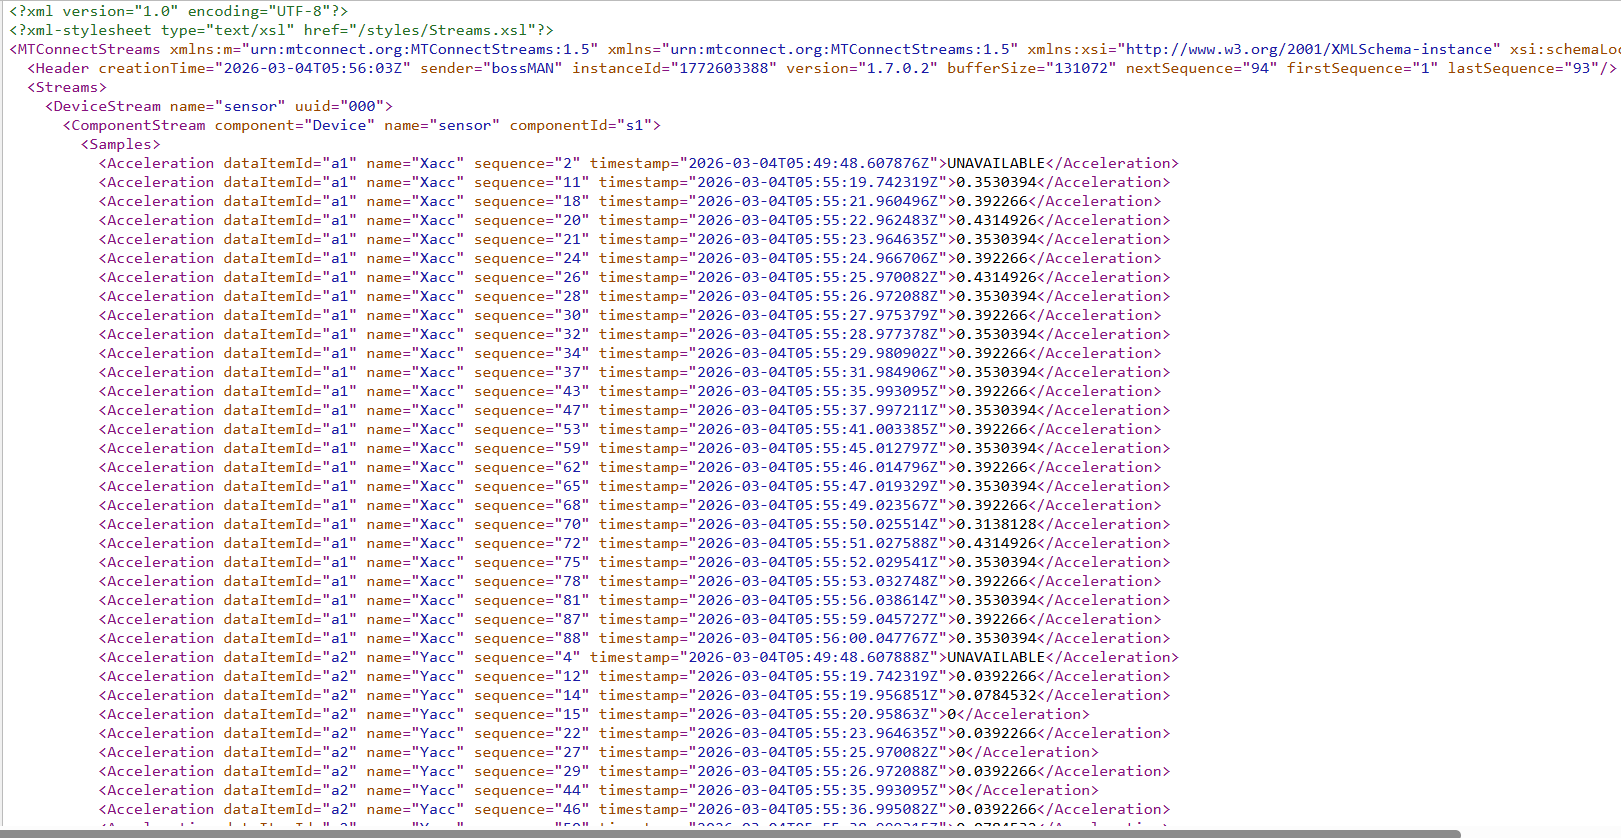
  ---





<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update/Lab5_fig12.PNG?raw=true" width="70%">

*Figure 12 Capture example for Task 3.1*


In [ ]:
#@markdown #### Write your HTTP request in the free-form text section below, e.g., http://192.168.1.2:5000/sample?from=100&count=20&path=somthing

T1 = 'http://127.0.0.1:5001/sample?from=100&count=20&path=//DataItem[@type=%22TEMPERATURE%22]|//DataItem[@type=%22HUMIDITY_RELATIVE%22]' #@param {type:"string",display-mode:"form"}

In [ ]:
#@title Task 3.2 What are the cons and pros of two MTConnect configurations (a single adapter vs. multiple adapters) to collect multiple sensors’ data? {display-mode:"form"}
T2_1 = 'Single Adapter: Pros - Simpler architecture, easier synchronization. Cons - Less modular, single point of failure Multiple adapter: Pros- Modular design, better fault tolerance Cons: Complex configuration, harder synchronization' #@param {type:"string"}



### Task 3.3

*※If you are not familiar with Python programming and XML parsing, do this Task at home.*

Perform Python XML parsing described below by loading the XML document (‘Lab5_TASK1.3.xml’) you saved in Task 1.3 and then attach the entire Python script to the report in the code block below. (Perform all in a single script.)
  
1. Print out ‘sender’, ‘firstSequence’, ‘nextSequence’, and ‘lastSequence’.
  
2. Print out each data element’s ‘name’, ‘timestamp’, and ‘value (or text)’

3. Capture the result in console or terminal, and then attach it to the report below:
    * Hint: Use [ElementTree XML API of Python](https://docs.python.org/3/library/xml.etree.elementtree.html)

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python 3 ([xml_parsing_example.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/xml_parsing_example/xml_parsing_example.py?raw=true))**

```
import xml.etree.ElementTree as ET

tree = ET.parse('xml_parsing_example.xml')  # create element tree object
root = tree.getroot()  # Get root element. root is the highest level of an xml tree which includes all the elements with lower levels.

print(root[0].attrib['instanceId'])  # Header is the element with index 0 under root. root[0].attrib is a dictionary with keys of "creationTime", "sender", etc.

```

---

The sample code (xml_parsing_example.py) is given as above. This code shows how to print the value of *'instanceId'* from *'header'* of file [xml_parsing_example.xml](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/xml_parsing_example/xml_parsing_example.xml?raw=true) (Figure 13).

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab5_xml_parsing_example.png?raw=tru" width="100%">

*Figure 13: xml_parsing_example.xml used in the example to print the value of 'instanceId'*

---

Place your screenshot for Task 3.3 here.
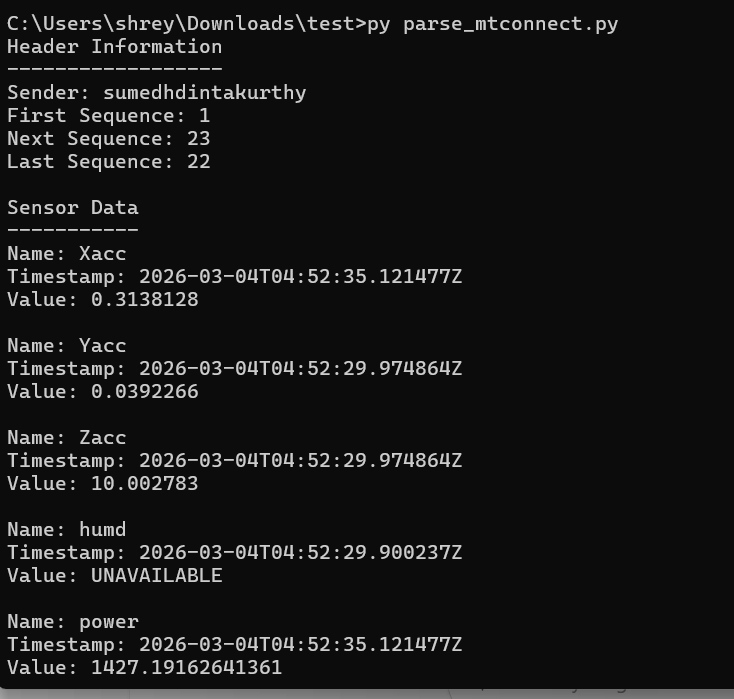
---

In [ ]:
# Place your code for Task 3.3 here:
#
import xml.etree.ElementTree as ET

# Load the XML file
tree = ET.parse("Lab5_TASK1.3.xml")
root = tree.getroot()

# Namespace used in MTConnect XML
ns = {"m": "urn:mtconnect.org:MTConnectStreams:1.5"}

# -----------------------------
# Print Header Information
# -----------------------------
header = root.find("m:Header", ns)

print("Header Information")
print("------------------")
print("Sender:", header.attrib["sender"])
print("First Sequence:", header.attrib["firstSequence"])
print("Next Sequence:", header.attrib["nextSequence"])
print("Last Sequence:", header.attrib["lastSequence"])
print()

# -----------------------------
# Print Sensor Data
# -----------------------------
print("Sensor Data")
print("-----------")

# Find all elements inside Samples and Events
elements = root.findall(".//m:Samples/*", ns) + root.findall(".//m:Events/*", ns)

for elem in elements:
    name = elem.attrib.get("name", "N/A")
    timestamp = elem.attrib.get("timestamp", "N/A")
    value = elem.text

    print("Name:", name)
    print("Timestamp:", timestamp)
    print("Value:", value)
    print()

#

## Lab5 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab5.

---

Write down A1 here.
We learnt how to use MTConnect with single and miltiple adapters
---


### Q2. What skills did you have to develop to accomplish this project?

---

Write down A2 here.
Parsing xml files was one new skill i learnt

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Write down A3 here.
everything

---

### Q4. What challenges did you encounter in completing the project?

---

Write down A4 here.
NA
---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Write down A5 here.
NA
---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)